<a href="https://colab.research.google.com/github/ran732/python-Libraries/blob/main/Pandas/Session_16_PANDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **What is Pandas**

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

https://pandas.pydata.org/about/index.html

# Pandas Series

A Pandas Series is like a column in a table. It is a 1-D array holding data of any type.

**Importing Pandas**


In [27]:
import numpy as np
import pandas as pd

In [28]:
#string
country = ['India','Pakistan','USA','Nepal','Germani','Itly']

pd.Series(country)

,0
0,India
1,Pakistan
2,USA
3,Nepal
4,Germani
5,Itly


In [29]:
#integer
runs = [13,34,23,54,90]

pd.Series(runs)

,0
0,13
1,34
2,23
3,54
4,90


In [100]:
#custom index
marks = [67,56,89,45,100]
subjects = ['Sanskrit','Hindi','English','Science','Math']

pd.Series(marks,index=subjects)

,0
Sanskrit,67
Hindi,56
English,89
Science,45
Math,100


In [31]:
#setting a name
pd.Series(marks,index=subjects,name="Ranjeet ke Marks")

,Ranjeet ke Marks
Sanskrit,67
Hindi,56
English,89
Science,45
Math,100


**Series from dict**

In [101]:
marks = {
    'Sanskrit':67,
    'Hindi':56,
    'English':89,
    'Science':45,
    'Math':100
}

make_series = pd.Series(marks,name='Ranjeet ke marks')
make_series

,Ranjeet ke marks
Sanskrit,67
Hindi,56
English,89
Science,45
Math,100


**Series Attributes**

In [33]:
#size
make_series.size

5

In [34]:
# dtype
make_series.dtype

dtype('int64')

In [35]:
#name
make_series.name

'Ranjeet ke marks'

In [36]:
#is_unique
make_series.is_unique   # True

pd.Series([1,1,2,3,4,5,6]).is_unique

False

In [37]:
#index
make_series.index

Index(['Sanskrit', 'Hindi', 'English', 'Science', 'Math'], dtype='object')

In [38]:
#values
make_series.values

array([ 67,  56,  89,  45, 100])

In [39]:
type(make_series.values)

numpy.ndarray

**Series using read_csv / real world data**

In [155]:
#with one col

# Naye Pandas versions me aise likhein
pd.read_csv('/subs.csv').squeeze("columns")  # explicitly convert data frame to series (squeeze)

#OR

# Agar column ka naam 'Subscribers' hai
subs = pd.read_csv('/subs.csv')['Subscribers gained']
subs


,Subscribers gained
0,48
1,57
2,40
3,43
4,44
...,...
360,231
361,226
362,155
363,144


In [41]:
# with 2 col
vk = pd.read_csv('/kohli_ipl.csv',index_col='match_no')['runs']
vk

,runs
match_no,
1,1
2,23
3,13
4,12
5,1
...,...
211,0
212,20
213,73


In [42]:
movies = pd.read_csv('/bollywood.csv',index_col='movie').squeeze('columns')

movies

,lead
movie,
Uri: The Surgical Strike,Vicky Kaushal
Battalion 609,Vicky Ahuja
The Accidental Prime Minister (film),Anupam Kher
Why Cheat India,Emraan Hashmi
Evening Shadows,Mona Ambegaonkar
...,...
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi


**Series methods**

In [43]:
# head() -> data from top & tail() -> data from buttom
subs.head()

,Subscribers gained
0,48
1,57
2,40
3,43
4,44


In [44]:
vk.head(3)

,runs
match_no,
1,1
2,23
3,13


In [45]:
vk.tail(5)

,runs
match_no,
211,0
212,20
213,73
214,25
215,7


In [46]:
# sample() -> put random row for the data
movies.sample()

,lead
movie,
Yadvi – The Dignified Princess,Prisha Aneja


In [47]:
vk.sample(5)

,runs
match_no,
100,13
50,11
89,21
206,0
159,23


In [48]:
#value_count() -> count the frequency of the data in given set

movies.value_counts()

,count
lead,
Akshay Kumar,48
Amitabh Bachchan,45
Ajay Devgn,38
Salman Khan,31
Sanjay Dutt,26
...,...
Seema Azmi,1
Akanksha Puri,1
Charanpreet Insan,1


In [49]:
#sort_values() -> inplace
vk.sort_values(ascending=False)

,runs
match_no,
128,113
126,109
123,108
120,100
164,100
...,...
93,0
130,0
206,0


In [50]:
vk.sort_values(ascending=False).head(1).values[0]     #[index -> values]

np.int64(113)

In [52]:
vk.sort_values(inplace=True)   #change permanent in original array

ValueError: This Series is a view of some other array, to sort in-place you must create a copy

In [53]:
s=[23,4,54,6,7,8,9,234]
pd.Series(s).sort_values(ascending=False)


,0
7,234
2,54
0,23
6,9
5,8
4,7
3,6
1,4


In [54]:
s

[23, 4, 54, 6, 7, 8, 9, 234]

In [55]:
s=[23,4,54,6,7,8,9,234]
so = pd.Series(s).sort_values(inplace=True)



In [57]:
so

In [56]:
#sort_index -> inplace ->movies
movies.sort_index(ascending=False)

,lead
movie,
Zor Lagaa Ke...Haiya!,Meghan Jadhav
Zokkomon,Darsheel Safary
Zindagi Tere Naam,Mithun Chakraborty
Zindagi Na Milegi Dobara,Hrithik Roshan
Zindagi 50-50,Veena Malik
...,...
2 States (2014 film),Arjun Kapoor
1971 (2007 film),Manoj Bajpayee
1920: The Evil Returns,Vicky Ahuja


***Series Math Methods***

In [58]:
#count -> can't count missing values  || size -> counts missing values
vk.count()

np.int64(215)

In [59]:
# sum / product
subs.sum()

np.int64(49510)

In [63]:
# mean / mode / median/ std / var
print(subs.mean())
print(vk.median())
print(movies.mode())
print(subs.std())
print(vk.var())

135.64383561643837
24.0
0    Akshay Kumar
Name: lead, dtype: object
62.67502303725269
688.0024777222344


In [62]:
#min / max
print(subs.min())
print(subs.max())

33
396


In [61]:
#describe  -> all mathematical operations
vk.describe()

,runs
count,215.000000
mean,30.855814
std,26.229801
min,0.000000
25%,9.000000
50%,24.000000
75%,48.000000
max,113.000000


In [60]:
subs.describe()

,Subscribers gained
count,365.000000
mean,135.643836
std,62.675023
min,33.000000
25%,88.000000
50%,123.000000
75%,177.000000
max,396.000000


**Series Indexing**

In [64]:
#interger indexing
x = pd.Series([12,34,4,54,56,3,34,56,67])
x[1]

np.int64(34)

In [65]:
#negative indexing work only string not integer
x[-1]

KeyError: -1

In [68]:
movies

,lead
movie,
Uri: The Surgical Strike,Vicky Kaushal
Battalion 609,Vicky Ahuja
The Accidental Prime Minister (film),Anupam Kher
Why Cheat India,Emraan Hashmi
Evening Shadows,Mona Ambegaonkar
...,...
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi


In [69]:
movies[0]  # default in pandas

/tmp/ipykernel_2423/3901301928.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movies[0]


'Vicky Kaushal'

In [70]:
movies['Uri: The Surgical Strike']

'Vicky Kaushal'

In [71]:
movies[-1]

/tmp/ipykernel_2423/2731571422.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movies[-1]


'Akshay Kumar'

In [77]:
make_series[-1]

/tmp/ipykernel_2423/2633256598.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  make_series[-1]


np.int64(100)

In [72]:
vk[-1]

KeyError: -1

In [79]:
#slicing
vk[5:16]

,runs
match_no,
6,9
7,34
8,0
9,21
10,3
11,10
12,38
13,3
14,11


In [81]:
#negative slicing
vk[-5:]

,runs
match_no,
211,0
212,20
213,73
214,25
215,7


In [82]:
movies[-5:]

,lead
movie,
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi
Company (film),Ajay Devgn
Awara Paagal Deewana,Akshay Kumar


In [83]:
#fancy indexing
vk[[1,3,4,7,9]]

,runs
match_no,
1,1
3,13
4,12
7,34
9,21


In [84]:
#indexing with labels -> fancy indexing
movies ['Saathiya (film)']

'Vivek Oberoi'

**Editing series**

In [102]:
# using indexing
make_series[0] = 80
make_series[1] = 89
make_series

/tmp/ipykernel_2423/3486276494.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  make_series[0] = 80
/tmp/ipykernel_2423/3486276494.py:3: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  make_series[1] = 89


,Ranjeet ke marks
Sanskrit,80
Hindi,89
English,89
Science,45
Math,100


In [104]:
#what if an index does not exist
make_series['sst'] = 87
make_series['ev'] = 87
make_series

,Ranjeet ke marks
Sanskrit,80
Hindi,89
English,89
Science,45
Math,100
sst,87
ev,87


In [109]:
#slicing
runs_ser =[34,5,6,76,78,34,98,77,54]
runs_ser = pd.Series(runs_ser)
runs_ser

,0
0,34
1,5
2,6
3,76
4,78
5,34
6,98
7,77
8,54


In [113]:
runs_ser[2:5] = [45,67,100]
runs_ser

,0
0,34
1,5
2,45
3,67
4,100
5,34
6,98
7,77
8,54


In [114]:
#fancy indexing
runs_ser[[1,7,8]] = [56,89,90]
runs_ser

,0
0,34
1,56
2,45
3,67
4,100
5,34
6,98
7,89
8,90


In [115]:
# using index label
movies['2 States (2014 film)'] = 'Alia Bhatt'
movies

,lead
movie,
Uri: The Surgical Strike,Vicky Kaushal
Battalion 609,Vicky Ahuja
The Accidental Prime Minister (film),Anupam Kher
Why Cheat India,Emraan Hashmi
Evening Shadows,Mona Ambegaonkar
...,...
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi


Copy and Views

**Series with Python Functionalities**

In [121]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs))
print(max(subs))
print(min(subs))

365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__firstlineno__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rd

In [122]:
#type conversion
list(make_series)

[80, 89, 89, 45, 100, 87, 87]

In [123]:
dict(make_series)

{'Sanskrit': np.int64(80),
 'Hindi': np.int64(89),
 'English': np.int64(89),
 'Science': np.int64(45),
 'Math': np.int64(100),
 'sst': np.int64(87),
 'ev': np.int64(87)}

In [125]:
#membership operator  work only index
'2 States (2014 film)' in movies

True

In [126]:
'Alia Bhatt' in movies

False

In [127]:
'Alia Bhatt' in movies.values

True

In [131]:
#looping
for i in movies:
  print(i,end=", ")

Vicky Kaushal, Vicky Ahuja, Anupam Kher, Emraan Hashmi, Mona Ambegaonkar, Geetika Vidya Ohlyan, Arshad Warsi, Radhika Apte, Kangana Ranaut, Nawazuddin Siddiqui, Ali Asgar, Ranveer Singh, Prit Kamani, Ajay Devgn, Sushant Singh Rajput, Amitabh Bachchan, Abhimanyu Dasani, Talha Arshad Reshi, Nawazuddin Siddiqui, Garima Agarwal, Rasika Agashe, Barun Sobti, Akshay Kumar, Zaheer Iqbal, Vidyut Jammwal, Deepika Amin, Manav Kaul, Naseeruddin Shah, Varun Dhawan, Shreyas Talpade, Tiger Shroff, Boman Irani, Ajay Devgn, Arjun Kapoor, Gavie Chahal, Prabhu Deva, Shahid Kapoor, Ayushmann Khurrana, Anupam Kher, Karanvir Bohra, Hrithik Roshan, Jimmy Sheirgill, John Abraham, Rishi Kapoor, Kangana Ranaut, Natalia Janoszek, Diljit Dosanjh, Sidharth Malhotra, Rajeev Khandelwal, Zaira Wasim, Akshay Kumar, Jacqueline Fernandez, Ayushmann Khurrana, Akshaye Khanna, Sonam Kapoor, Karan Deol, Sanjay Dutt, Bhavesh Kumar, Sanaya Irani, Ayushmann Khurrana, Siddhanth Kapoor, Akshay Kumar, Taapsee Pannu, Rajkummar Rao

In [132]:
for i in movies.index:
  print(i,end=", ")

Uri: The Surgical Strike, Battalion 609, The Accidental Prime Minister (film), Why Cheat India, Evening Shadows, Soni (film), Fraud Saiyaan, Bombairiya, Manikarnika: The Queen of Jhansi, Thackeray (film), Amavas, Gully Boy, Hum Chaar, Total Dhamaal, Sonchiriya, Badla (2019 film), Mard Ko Dard Nahi Hota, Hamid (film), Photograph (film), Risknamaa, Mere Pyare Prime Minister, 22 Yards, Kesari (film), Notebook (2019 film), Junglee (2019 film), Gone Kesh, Albert Pinto Ko Gussa Kyun Aata Hai?, The Tashkent Files, Kalank, Setters (film), Student of the Year 2, PM Narendra Modi, De De Pyaar De, India's Most Wanted (film), Yeh Hai India, Khamoshi (2019 film), Kabir Singh, Article 15 (film), One Day: Justice Delivered, Hume Tumse Pyaar Kitna, Super 30 (film), Family of Thakurganj, Batla House, Jhootha Kahin Ka, Judgementall Hai Kya, Chicken Curry Law, Arjun Patiala, Jabariya Jodi, Pranaam, The Sky Is Pink, Mission Mangal, Saaho, Dream Girl (2019 film), Section 375, The Zoya Factor (film), Pal Pa

In [136]:
# Arithmatic operator  (Broadcasting)
100 - make_series

,Ranjeet ke marks
Sanskrit,20
Hindi,11
English,11
Science,55
Math,0
sst,13
ev,13


In [138]:
#Relational Operator
vk[vk >= 50]  #vk[condition -> bool]

,runs
match_no,
15,50
34,58
41,71
44,56
45,67
52,70
57,57
68,73
71,51


**Boolean Indexing on Series**


In [144]:
# Find no of 50's and 100's scored by kohli
vk[vk >= 50].size

50

In [146]:
# find number of ducks
vk[vk==0].size

9

In [159]:
# Count number of day when I had more than 200 subs a day
subs[subs >= 200].size

59

In [166]:
# find actors who have done more than 20 movies
num_movies = movies.value_counts()
num_movies[num_movies > 20]

,count
lead,
Akshay Kumar,48
Amitabh Bachchan,45
Ajay Devgn,38
Salman Khan,31
Sanjay Dutt,26
Shah Rukh Khan,22
Emraan Hashmi,21


**Plotting Graphs on Series**

<Axes: >

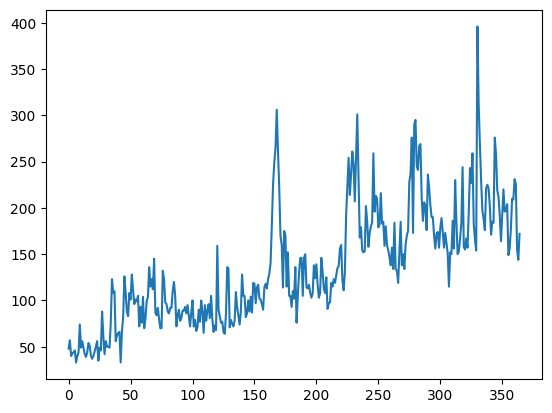

In [167]:
subs.plot()

<Axes: xlabel='lead'>

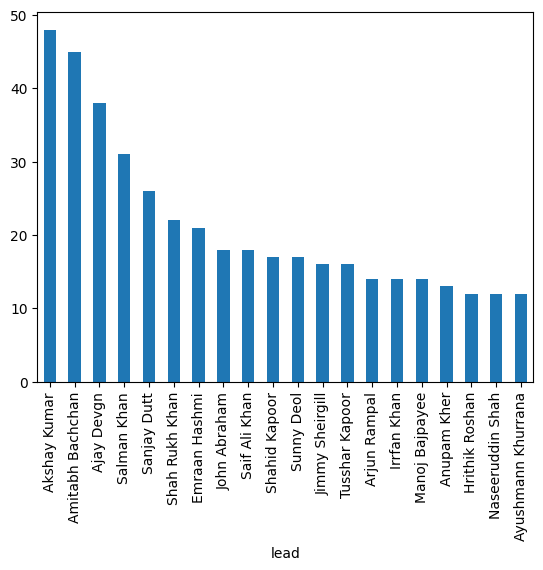

In [172]:
movies.value_counts().head(20).plot(kind='bar')

<Axes: ylabel='count'>

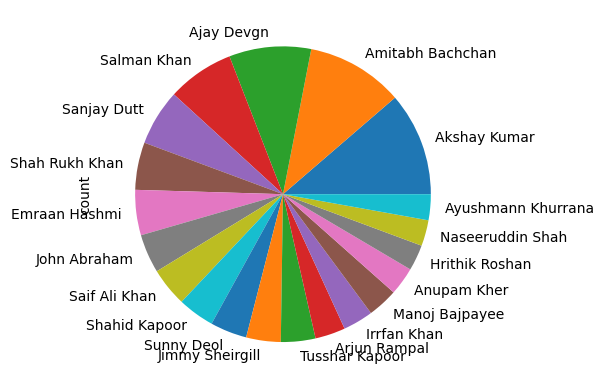

In [175]:
movies.value_counts().head(20).plot(kind='pie')

**Some Important Series Methods**

In [176]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy